In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import os

In [2]:
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# 1. Загрузка данных

In [3]:
import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(path)

C:\Users\Admin\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [4]:
files = os.listdir(path)
print("Файлы в датасете:")
for f in files:
    print(f)

Файлы в датасете:
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [5]:
df_orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
df_items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
df_products = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
df_customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
df_payments = pd.read_csv(os.path.join(path, 'olist_order_payments_dataset.csv'))
df_category = pd.read_csv(os.path.join(path, 'product_category_name_translation.csv'))

In [6]:
print(df_orders.isna().sum())
df_orders.head()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_approved_at'] = pd.to_datetime(df_orders['order_approved_at'])
df_orders['order_delivered_carrier_date'] = pd.to_datetime(df_orders['order_delivered_carrier_date'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

In [8]:
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'])

In [10]:
print(df_products.isna().sum())
df_products.head()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [11]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [12]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [13]:
df_category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


###  Выводы по этапу предобработки данных

* **Типы данных и дубликаты:** Значения дат успешно приведены к формату `datetime`. Критических дубликатов в данных не обнаружено.
* **Пропуски в `df_orders`:** Не являются ошибкой. Они логичны и связаны с бизнес-процессом маркетплейса: часть заказов ещё не прошла полный цикл и находится на разных стадиях (например, в процессе доставки).
* **Пропуски в `df_products`:** Обнаружено небольшое количество пропусков. На текущем этапе они оставлены как есть, так как не влияют на расчет базовых метрик. Решение об их заполнении или удалении будет принято далее при необходимости.

# 2. Статусы заказов

In [14]:
df_orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [15]:
print(f"Доля доставленных заказов: {round((df_orders[df_orders['order_status'] == 'delivered'].shape[0]) / 
                                          (df_orders['order_status'].shape[0]), 4) * 100}%")

Доля доставленных заказов: 97.02%


Временной диапозон

In [16]:
max_period = df_orders['order_purchase_timestamp'].max().to_period('M')
min_period = df_orders['order_purchase_timestamp'].min().to_period('M')

print(f"Дата первого заказа: {df_orders['order_purchase_timestamp'].min()}")
print(f"Дата последнего заказа: {df_orders['order_purchase_timestamp'].max()}")
print(f"Количество месяцев: {(max_period - min_period).n}")

Дата первого заказа: 2016-09-04 21:15:19
Дата последнего заказа: 2018-10-17 17:30:18
Количество месяцев: 25


Клиенты и заказы

In [17]:
df_orders_customers = pd.merge(df_orders, df_customers, on='customer_id')
df_orders_customers = df_orders_customers[df_orders_customers['order_status'] == 'delivered']

In [18]:
print(f"Количество уникальных клиентов: {df_orders_customers['customer_unique_id'].nunique()}")
print(f"Среднее количество доставленных заказов на клиента: {round(df_orders_customers['order_id'].nunique() / 
                                                                  df_orders_customers['customer_unique_id'].nunique(), 4)}")

Количество уникальных клиентов: 93358
Среднее количество доставленных заказов на клиента: 1.0334


In [19]:
df_orders_customers['order_month'] = df_orders_customers['order_purchase_timestamp'].dt.to_period('M').astype(str)

In [20]:
df_counts_orders = df_orders_customers.groupby('order_month')['order_id'].count().reset_index()
df_counts_orders = df_counts_orders.rename(columns={'order_id' : 'cnt_order'})

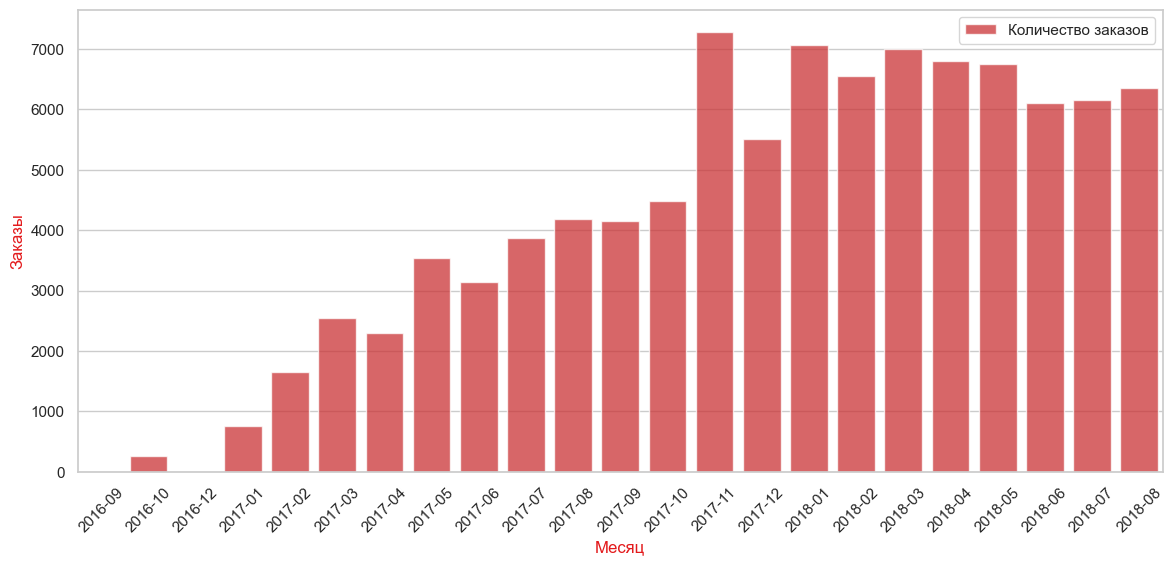

In [21]:
plt.figure(figsize=(14, 6))

sns.barplot(df_counts_orders, x='order_month', y='cnt_order', alpha=0.75, color='#e31a1c', label='Количество заказов')

plt.xlabel('Месяц', color='#e31a1c')
plt.ylabel('Заказы', color='#e31a1c')
plt.xticks(rotation=45)
plt.show()

##  Первичный анализ данных (EDA) и ключевые выводы

###  1. Общий объем данных
* База данных состоит из **9 взаимосвязанных таблиц**. Ключевой является таблица заказов (`df_orders`), содержащая информацию о **~99 тыс. транзакций**.
* Доля успешно доставленных заказов составляет **97%** (`status == 'delivered'`), что говорит о стабильной работе логистики. Остальные статусы встречаются редко и будут исключены из анализа, так как для расчета корректного RFM-скора нам необходимы только завершенные торговые операции.

###  2. Временной диапазон и тренды
* Данные охватывают период с **04.09.2016 по 17.10.2018** (около 25 полных месяцев). 
* На протяжении всего периода наблюдается устойчивый **восходящий тренд** с элементами сезонных колебаний.
* Абсолютный пик продаж зафиксирован в **ноябре 2017 года**. Это напрямую обусловлено глобальными распродажами — Черной пятницей (24 ноября) и Киберпонедельником (27 ноября).

###  3. Качество данных и структура
* **Пропуски:** Обнаружены в `df_orders` (связаны с естественным ходом логистических этапов для недоставленных заказов) и в `df_products` (отсутствуют категории у некоторых товаров). В критически важных полях-идентификаторах (`order_id`, `customer_unique_id`) пропусков нет.
* **Дубликаты строк:** Полные дубликаты в таблицах отсутствуют.
* **Специфика `df_items`:** Обнаружены повторяющиеся комбинации ключей `['order_id', 'product_id']`. Это нормальная бизнес-логика: клиент купил несколько единиц одного и того же товара в рамках одного заказа. Для корректного расчета выручки (Monetary) данные строки будут предварительно сгруппированы.

###  4. Клиенты и метрики удержания
* В выборке зафиксировано около **93 тыс. уникальных клиентов**.
* Среднее количество заказов на одного покупателя составляет всего **1.03**. Это ключевой инсайт экспресс-анализа: клиенты практически не возвращаются за повторными покупками. Метрика **Retention Rate** является главной проблемной зоной и одновременно ключевой точкой роста для бизнеса.

---

###  Итог этапа разведки данных
Исходные данные обладают высоким качеством, репрезентативны и готовы к расчету бизнес-метрик без проведения тяжелой токсичной очистки. Дальнейшие шаги будут направлены на объединение таблиц, агрегацию товарных позиций в чеках и фильтрацию по успешно завершенным заказам.

# 3. Воронка конверсий

In [22]:
# Все уникальные пользователи
total_users = df_customers['customer_unique_id'].nunique()

# Пользователи с любым заказом
orders_all = pd.merge(df_orders, df_customers, on='customer_id')
users_with_orders = orders_all['customer_unique_id'].nunique()

# Пользователи у которых есть хотя бы один заказ, и он не отменен
orders_not_canceled = df_orders[df_orders['order_status'] != 'canceled']
orders_not_canceled_with_customer = pd.merge(orders_not_canceled, df_customers, on='customer_id')
users_with_not_canceled = orders_not_canceled_with_customer['customer_unique_id'].nunique()

# Пользователи с доставленным заказом
users_with_delivered = df_orders_customers['customer_unique_id'].nunique()

# Считаем проценты
funnel_data = pd.DataFrame({
    'step' : ['Все пользователи', 'Хотя бы 1 заказ', 'Хотя бы 1 заказ и не отменен', 'Доставленный заказ'],
    'users' : [total_users, users_with_orders,  users_with_not_canceled, users_with_delivered],
    'pct_from_start' : [100, users_with_orders/total_users*100, users_with_not_canceled/total_users*100, users_with_delivered/total_users*100]})
print(funnel_data)

                           step  users  pct_from_start
0              Все пользователи  96096      100.000000
1               Хотя бы 1 заказ  96096      100.000000
2  Хотя бы 1 заказ и не отменен  95560       99.442224
3            Доставленный заказ  93358       97.150766


In [23]:
print(f"Распределение статусов заказов: {df_orders['order_status'].value_counts(normalize=True) * 100}")

Распределение статусов заказов: order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64


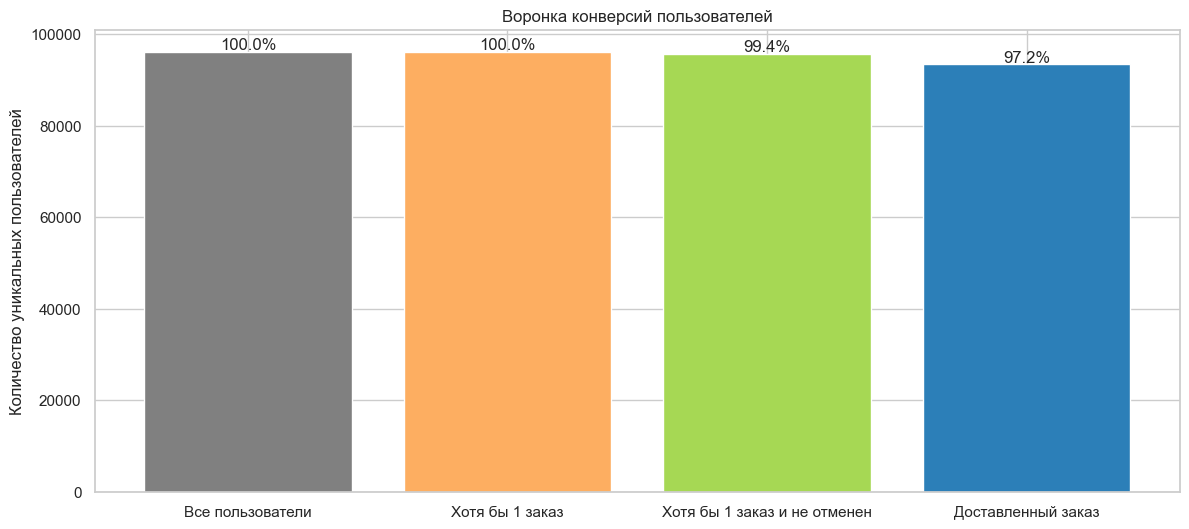

In [24]:
plt.figure(figsize=(14, 6))
bars = plt.bar(funnel_data['step'], funnel_data['users'], color=['gray', '#fdae61', '#a6d854', '#2c7fb8'])
plt.title('Воронка конверсий пользователей')
plt.ylabel('Количество уникальных пользователей')
for bar, pct in zip(bars, funnel_data['pct_from_start']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{pct:.1f}%', ha='center')
plt.show()

###  Анализ структуры статусов и операционной эффективности
* **Минимальный уровень отмен:** анализ воронки показал, что допущенные отмены (`status == 'canceled'`) составляют всего **~0.6%** от общего числа транзакций. Это очень низкий показатель для e-commerce, который подтверждает высокую надежность ландшафта продаж.
* **Природа разрыва в данных:** Разница между метриками «всего заказов» и «доставлено» обусловлена не системными сбоями или возвратами, а **активными заказами в транзитных статусах** (находящимися в процессе сборки, сортировки или логистической транспортировки на момент формирования отчета).
* **Бизнес-вывод:** Операционные и логистические процессы маркетплейса хорошо отлажены. Бизнес не страдает от массовых операционных потерь, что позволяет с полной уверенностью использовать подвыборку успешно доставленных заказов как максимально репрезентативную и очищенную от шума для дальнейшего исследования.

# 4. Когортный анализ Retention

In [25]:
df_first_purchase = df_orders_customers.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
df_first_purchase = df_first_purchase.rename(columns={'order_purchase_timestamp' : 'first_purchase_date'})

df_first_purchase['cohort_month'] = df_first_purchase['first_purchase_date'].dt.to_period('M')

In [26]:
df_orders_cohorts = pd.merge(df_orders_customers, df_first_purchase, on='customer_unique_id')

In [27]:
order_year = df_orders_cohorts['order_purchase_timestamp'].dt.year
order_month = df_orders_cohorts['order_purchase_timestamp'].dt.month

first_year = df_orders_cohorts['first_purchase_date'].dt.year
first_month = df_orders_cohorts['first_purchase_date'].dt.month

df_orders_cohorts['cohort_index'] = (order_year - first_year) * 12 + (order_month - first_month)

In [28]:
df_cohort_counts = df_orders_cohorts.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()

cohort_matrix = df_cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

In [29]:
cohort_size = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0)

<function matplotlib.pyplot.show(close=None, block=None)>

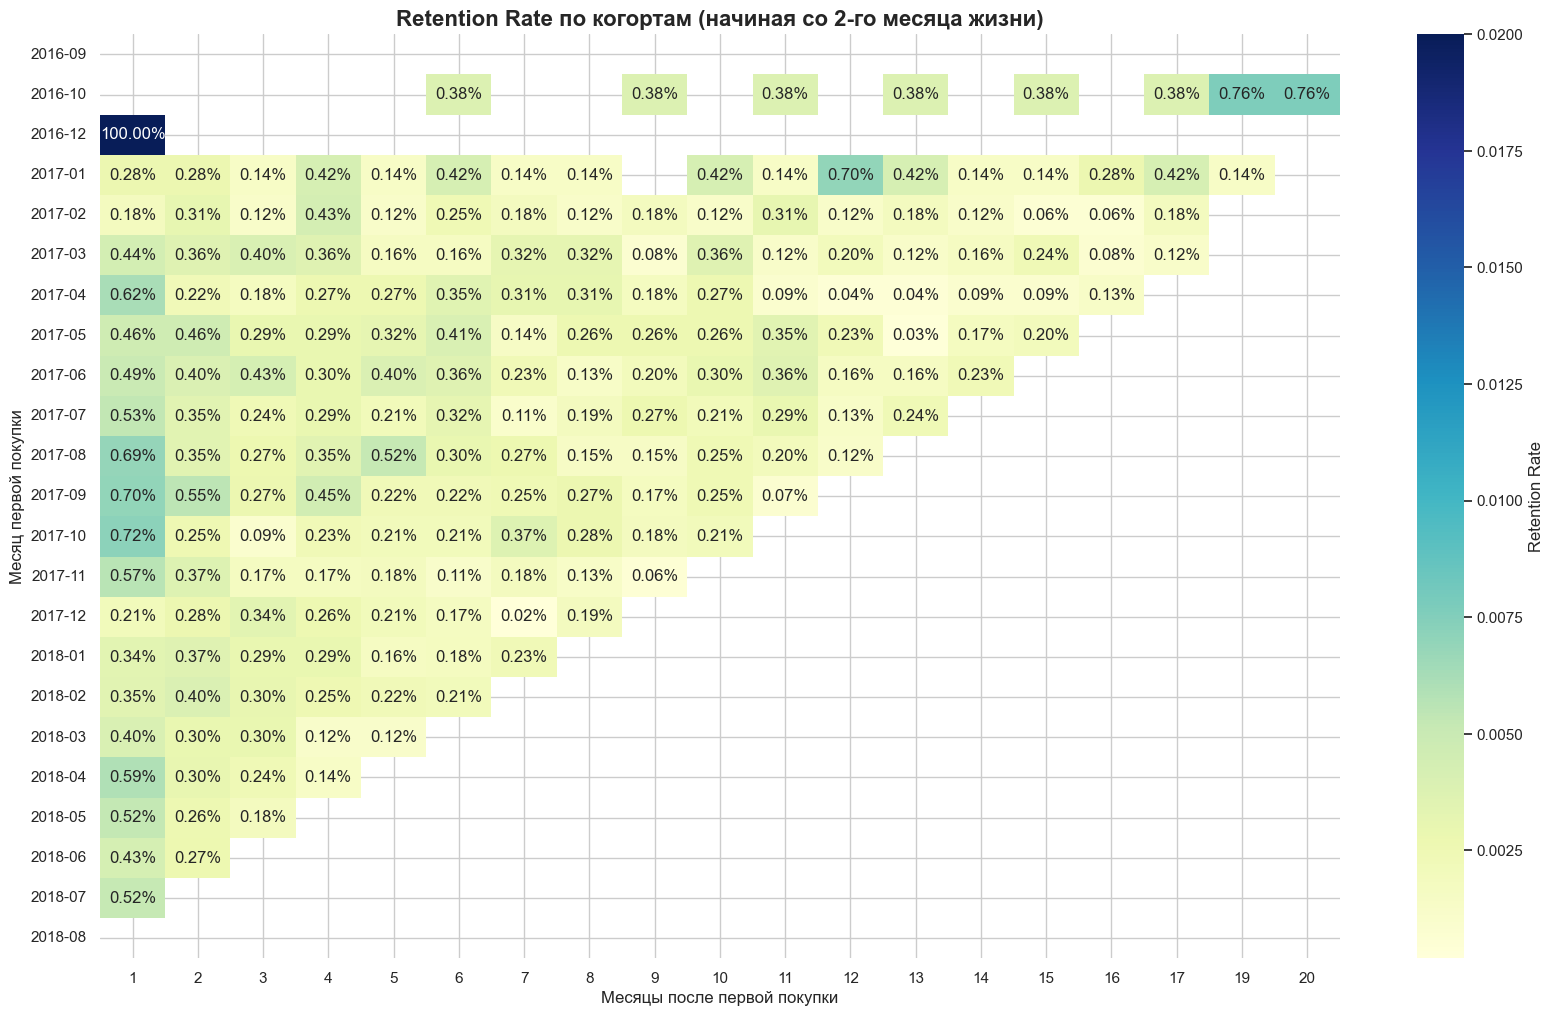

In [30]:
plt.figure(figsize=(20, 12))

sns.heatmap(retention_matrix.iloc[:, 1:], 
            annot=True, 
            fmt='.2%', 
            cmap='YlGnBu', 
            vmax=0.02, 
            cbar_kws={'label': 'Retention Rate'})

plt.title('Retention Rate по когортам (начиная со 2-го месяца жизни)', fontsize=16, fontweight='bold')
plt.xlabel('Месяцы после первой покупки', fontsize=12)
plt.ylabel('Месяц первой покупки', fontsize=12)

plt.show

## Анализ матрицы удержания (Retention Heatmap) и ключевые инсайты

На основе построенной тепловой карты когортного анализа были сформулированы следующие выводы:

* **Критически низкий уровень повторных продаж:** Коэффициент удержания (Retention Rate) в первый месяц после совершения покупки варьируется в диапазоне всего **0.2% – 0.7%**. Данный паттерн полностью подтверждает ранее рассчитанную метрику среднего количества заказов на одного клиента (1.03). Бизнес критически зависит от постоянного притока холодного трафика (User Acquisition), не формируя органическую базу повторных покупок.
* **Технический артефакт в когорте (2016-12):** В когорте декабря 2016 года наблюдается аномальный всплеск Retention до 100%. Углубленный аудит исходных данных показал, что это системный шум — единичные тестовые заказы на этапе отладки платформы. Данная когорта не является репрезентативной для реального пользовательского поведения и исключена из дальнейшего моделирования.
* **Маркетинговые паттерны (Осень 2017):** В когортах сентября и октября 2017 года фиксируются показатели удержания выше среднерыночных значений для данной платформы (**0.69% – 0.72%**). Этот всплеск обусловлен качественным прогревом аудитории и реактивацией пользователей перед масштабной ноябрьской распродажей (Черная пятница и Киберпонедельник).
* **Бизнес-рекомендация по коммуникациям:** Проведение массовых «ковровых» рассылок (email/push) по всей базе экономически нецелесообразно и приведет к неэффективному сжиганию маркетингового бюджета. Вместо этого необходимо отказаться от массового спама в пользу **микросегментации аудитории** и точечной работы с узкими, более отзывчивыми когортами пользователей.

# 5. RFM - сегментация

In [31]:
df_last_purchase = df_orders_customers.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
df_last_purchase = df_last_purchase.rename(columns={'order_purchase_timestamp' : 'last_purchase'})

In [32]:
now_date = df_orders_customers['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [33]:
df_last_purchase['recency'] = (now_date - df_last_purchase['last_purchase']).dt.days

In [34]:
df_frequency = df_orders_customers.groupby('customer_unique_id')['order_id'].nunique().reset_index()
df_frequency.columns = ['customer_unique_id', 'frequency']

In [35]:
df_price = df_items.groupby('order_id')['price'].sum().reset_index()

In [36]:
df_orders_customers = pd.merge(df_orders_customers, df_price, on='order_id')

In [37]:
df_monetary = df_orders_customers.groupby('customer_unique_id')['price'].sum().reset_index()
df_monetary.columns = ['customer_unique_id', 'monetary']

In [38]:
df_rfm = pd.merge(df_last_purchase[['customer_unique_id', 'recency']], df_frequency, how='left', on='customer_unique_id')
df_rfm = pd.merge(df_rfm, df_monetary, how='left', on='customer_unique_id')

In [39]:
df_rfm['frequency'].value_counts()

frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [40]:
df_rfm['r_score'] = pd.qcut(df_rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])
df_rfm['f_score'] = df_rfm['frequency'].clip(upper=3)
df_rfm['m_score'] = pd.qcut(df_rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])

In [41]:
df_rfm['rfm_score'] = df_rfm['r_score'].astype(str) + df_rfm['f_score'].astype(str) + df_rfm['m_score'].astype(str)

In [42]:
def get_segment(score):
    r, f, m = int(score[0]), int(score[1]), int(score[2])    
    if r >= 4 and f == 3:
        return 'Champions'
    elif r >= 4 and f == 2:
        return 'Loyal Customers'
    elif r >= 4 and f == 1:
        return 'Promising / New'
    elif r == 3:
        return 'About to Sleep'
    elif r <= 2 and f >= 2:
        return 'Cant Lose Them'
    else:
        return 'Lost'

In [43]:
df_rfm['segment'] = df_rfm['rfm_score'].apply(get_segment)
df_rfm[['customer_unique_id', 'rfm_score', 'segment']].head()

,customer_unique_id,rfm_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,414,Promising / New
1,0000b849f77a49e4a4ce2b2a4ca5be3f,411,Promising / New
2,0000f46a3911fa3c0805444483337064,112,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,211,Lost
4,0004aac84e0df4da2b147fca70cf8255,215,Lost


In [44]:
df_segments_summary = df_rfm.groupby('segment').agg(
    customer_count = ('customer_unique_id', 'count'),
    total_monetary = ('monetary', 'sum')
).reset_index()

df_segments_summary['customer_share_%'] = (df_segments_summary['customer_count'] / df_segments_summary['customer_count'].sum() * 100).round(2)
df_segments_summary['revenue_share_%'] = (df_segments_summary['total_monetary'] / df_segments_summary['total_monetary'].sum() * 100).round(2)
df_segments_summary = df_segments_summary.sort_values('customer_count', ascending=False)
df_segments_summary

,segment,customer_count,total_monetary,customer_share_%,revenue_share_%
3,Lost,36228,5060241.40,38.81,38.27
5,Promising / New,36224,5082965.30,38.80,38.44
0,About to Sleep,18709,2508084.26,20.04,18.97
4,Loyal Customers,1087,269812.60,1.16,2.04
1,Cant Lose Them,988,243556.29,1.06,1.84
2,Champions,122,56838.26,0.13,0.43


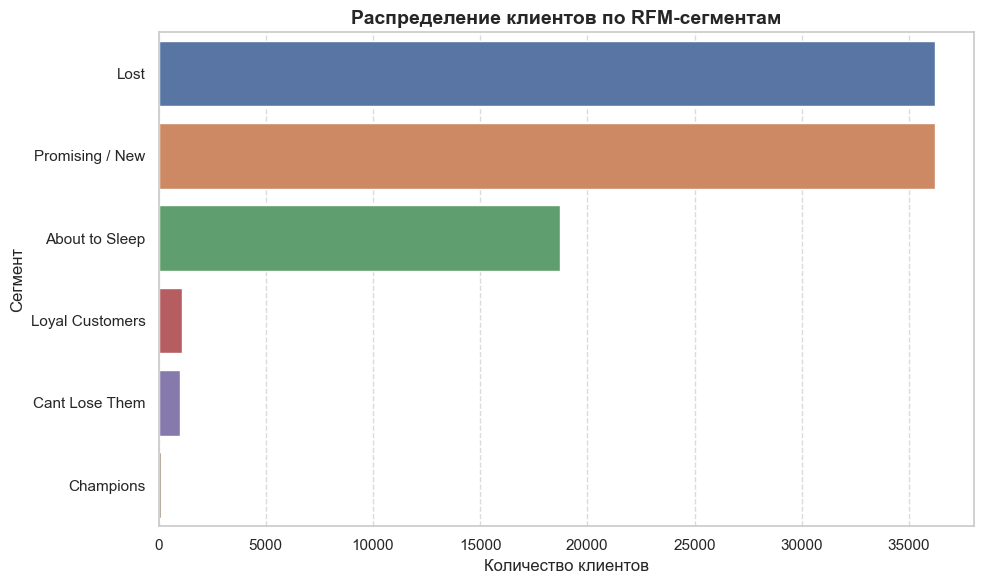

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_segments_summary, x='customer_count', y='segment', hue='segment')

plt.title('Распределение клиентов по RFM-сегментам', fontsize=14, fontweight='bold')
plt.xlabel('Количество клиентов', fontsize=12)
plt.ylabel('Сегмент', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

## Анализ распределения RFM-сегментов и продуктовая стратегия

Финальная визуализация распределения клиентов по сегментам подсветила ключевые уязвимости и точки роста маркетплейса:

* **Доминирование «одноразовых» клиентов:** Порядка **78% всей клиентской базы** — это либо новые пользователи либо старые «уснувшие» клиенты, совершившие лишь одну покупку. Для e-commerce бизнеса это создает большие риски для долгосрочного развития: компания тратит огромные бюджеты на маркетинг и рекламу , но клиенты уходят сразу после первой транзакции.
* **Парадокс лояльного ядра (слом правила Парето):** Три самые ценные и лояльные группы клиентов суммарно составляют **менее 3% от общего объема базы** и приносят компании всего **около 4% прибыли**. Стабильное ядро регулярных покупателей, способное обеспечивать маржинальность без постоянного рекламного давления, на платформе практически отсутствует.

###  Комплекс мер по удержанию пользователей и максимизации LTV:

1. **Разрушение барьера второго заказа:** Внедрить автоматический триггерный промокод со скидкой на **вторую покупку**, отправляемый через 14–30 дней после первой доставки. Переход из первой транзакции во вторую — самое узкое горлышко текущей воронки.
2. **Персонализация CRM-маркетинга:** Настроить кастомизированные email- и push-кампании с персональными подборками товаров на основе категорий и интересов, проявленных пользователем при его единственном заказе.
3. **Ступенчатая программа лояльности:** Разработать многоуровневую бонусную систему (накопительные баллы или кешбэк), в которой процент выгоды для клиента растет пропорционально частоте его покупок (*«больше покупаешь — выше статус и скидка»*). Это простимулирует пользователей возвращаться и делать повторные покупки.